# LLaMa 3 architecture

# Llama 3 vs Llama 2 Comparison

| **FEATURE** | **Llama 3** | **Llama 2** |
|-------------|-------------|-------------|
| Tokenizer | Tiktoken (developed by OpenAI) | SentencePiece |
| Number of Parameters | 8B, 70B | 70B, 13B, 7B |
| Training Data | 15T tokens | 2.2T tokens |
| Context Length | 8192 tokens | 4096 tokens |
| Attention Mechanism | Grouped-query attention | Grouped-query attention |
| Fine-Tuned Models | Yes | Yes |
| Performance | Better than Llama 2 on all benchmarks | Better than Llama 1 on most benchmarks |
| Computational Requirements | Very high (70B model) | Very high (70B model) |
| Availability | Open source | Open source |
| Reinforcement learning from human feedback | Yes | Yes |
| Number of languages supported | 30 languages | 20 languages |
| Suitable for | Best for more demanding tasks, such as reasoning, coding, and proficiency tests | Good for more demanding tasks, such as reasoning, coding, and proficiency tests |

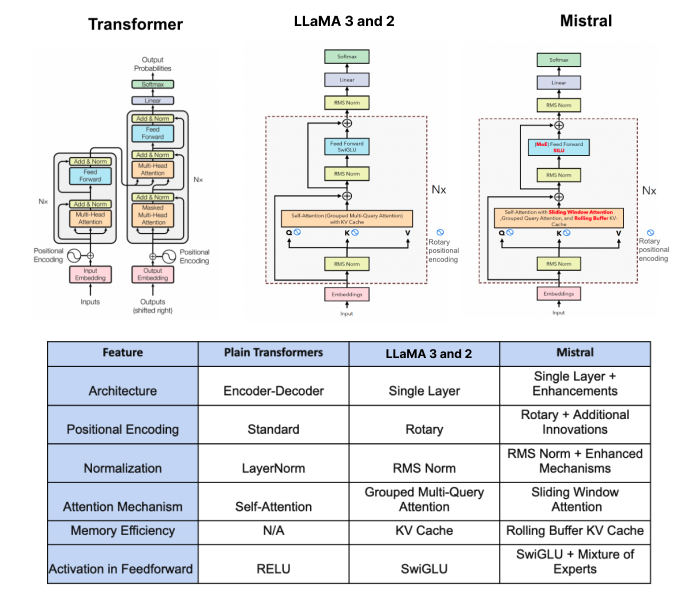

## RMSNorm

### What is RMSNorm?
RMSNorm is a normalization technique that normalizes the inputs to a layer by their root mean square (RMS) value, rather than using both mean and variance like traditional LayerNorm.
RMSNorm (Root Mean Square Normalization) is a normalization technique similar to LayerNorm but without mean subtraction. Instead of centering the input, RMSNorm simply scales it by the root mean square of its values and applies a learned scaling factor.

$$
\text{RMSNorm}(x) = \frac{x}{\sqrt{\frac{1}{d} \sum_{i=1}^{d} x_i^2 + \epsilon}} \cdot w
$$

- \( x \): Input vector  
- \( d \): Hidden dimension  
- \( $\epsilon$ \): Small constant for numerical stability  
- \( w \): Learnable scaling vector


### Analogy

Imagine you're studying for a big exam, and you have a massive textbook full of chapters. Each chapter represents a different topic, but some chapters are more crucial for understanding the subject than others.<br> 
Now, before diving into the entire textbook, you decide to evaluate the importance of each chapter. You don't want to spend the same amount of time on every chapter; you want to focus more on the critical ones. This is where Pre-normalization using RMSNorm comes into play for large language models (LLMs) like ChatGPT. It's like assigning a weight to each chapter based on its significance. Chapters that are fundamental to the subject get higher weights, while less important ones get lower weights.<br>
So, before going deeply into studying, you adjust your study plan based on the weighted importance of each chapter. You allocate more time and effort to the chapters with higher weights, ensuring you grasp the core concepts thoroughly.<br>
Similarly, Pre-normalization using RMSNorm helps LLMs prioritize which parts of the text are more critical for understanding the context and meaning. It assigns higher weights to essential elements and lower weights to less crucial ones, ensuring the model focuses its attention where it's most needed for accurate comprehension.<br>


### Comparison: LayerNorm vs RMSNorm

| Feature                 | LayerNorm                          | RMSNorm                            |
|------------------------|-------------------------------------|-------------------------------------|
| **Mean subtraction**   | ✅ Yes                             | ❌ No                              |
| **Variance normalization** | ✅ Uses standard deviation     | ✅ Uses root mean square           |
| **Computation cost**   | ❌ Higher (mean + variance)         | ✅ Lower (only squared sum)        |
| **Memory efficiency**  | ❌ Less                            | ✅ More                            |
| **Normalization type** | Scale + Center                      | Scale only                         |
| **Used in**            | BERT, GPT-2                         | LLaMA, Falcon, Mistral             |

## SwiGLU
SwiGLU is an activation function used in neural networks, particularly in transformer models. It's a combination of the Swish and GLU (Gated Linear Unit) activation functions.
- **Swi** refers to the Swish activation function
- **GLU** stands for Gated Linear Unit

### Swish

Swish is a smooth, non-monotonic — function that does not consistently increase or decrease — activation function defined as :
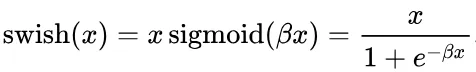

β is a trainable parameter, but most implementations do not use it, 
setting β = 1 and simplifying the function to : ```swish(x) = x * sigmoid(x)``` <br>
which is equivalent to the Sigmoid Linear Unit or SiLU.

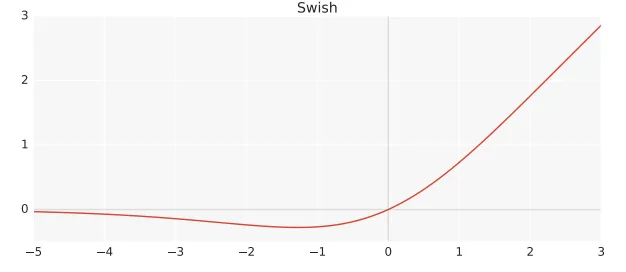
Swish has been shown to outperform ReLU in many applications. **Its main advantage is that it provides a smoother transition around 0, which leads to better optimization and faster convergence.**

### GLU (Gated Linear Unit)
The idea behind this function is that it takes the output of a linear transformation and splits it into two parts: one part is passed through another linear transformation, while the second is passed through a sigmoid activation function. This is illustrated in the following formula:
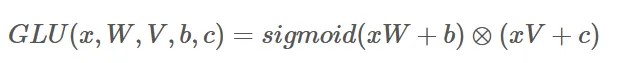

**The output of each layer is a linear projection x∗ W + b modulated by the gates σ(x ∗ V + c). Similar to LSTMs, these gates multiply each element of the matrix x∗W+b and control the information passed on in the hierarchy.**

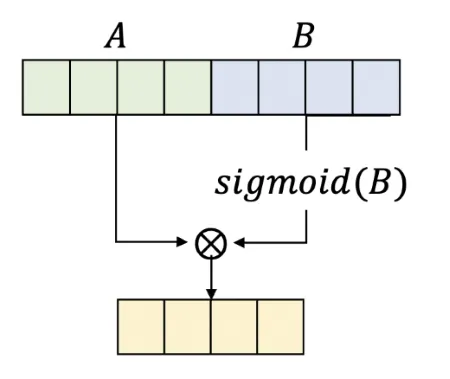

To sum up GLU enables the network to focus on important features by either passing or blocking information, and it has shown to be useful in tasks like sequence modeling, machine translation, and language modeling

### SwiGLU
SwiGLU is a combination of both Swish and GLU. It is basically a GLU, but instead of using the sigmoid function, we use Swish with β = 1<br>

SwiGLU combines two key components:
1. **Gating mechanism**: It uses a gate to control information flow, similar to how LSTM gates work
2. **Swish activation**: Instead of using sigmoid or other activations, it uses the Swish function (x * sigmoid(x))

The mathematical formula is:

```
SwiGLU(x) = Swish(xW + b) ⊙ (xV + c)
```

Where:
- `x` is the input
- `W` and `V` are different weight matrices
- `b` and `c` are bias terms
- `⊙` represents element-wise multiplication
- `Swish(x) = x * sigmoid(x)`

### Analogy
Imagine you're a teacher trying to explain a complex topic to your students. You have a big whiteboard where you write down key points and draw diagrams to make things clearer. But sometimes, your handwriting might not be very neat, or your diagrams might not be perfectly drawn. This can make it harder for your students to understand the material.

Now, imagine if you had a magic pen that automatically adjusted the size and style of your handwriting based on how important each point is. If something is really crucial, the pen writes it bigger and clearer, making it stand out. If it's less important, the pen writes it smaller, but still legible. SwiGLU is like that magic pen for large language models (LLMs) like ChatGPT. Before generating text, SwiGLU adjusts the importance of each word or phrase based on its relevance to the context. Just like the magic pen adjusts the size and style of your writing, SwiGLU adjusts the emphasis of each word or phrase.

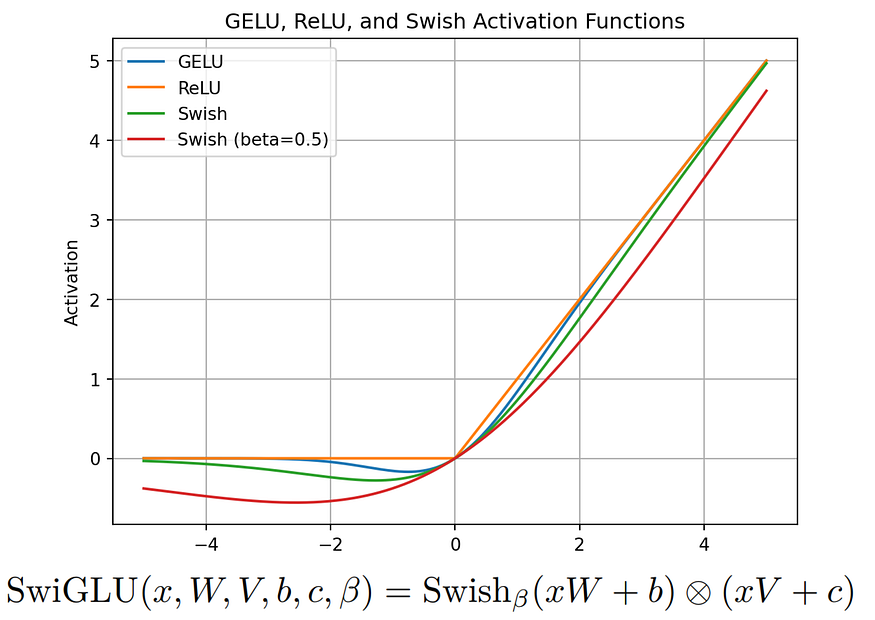

So, when the LLM generates text, it can give more prominence to the important parts, making them more noticeable and ensuring they contribute more to the overall understanding of the text. This way, SwiGLU helps LLMs produce text that's clearer and easier to understand, much like how the magic pen helps you create clearer explanations for your students on the whiteboard. 

### Key advantages

- **Better performance**: Often outperforms ReLU and other activation functions in language models
- **Smooth gradients**: The Swish component provides smoother gradients than ReLU, which can help with training
- **Selective information flow**: The gating mechanism allows the network to selectively pass information

### Where it's used

SwiGLU has been adopted in several prominent models:

- PaLM (Google's large language model)
- LLaMA (Meta's language model family)
- Various other transformer architectures

### Summary

The function essentially learns to decide what information to pass through (via the gate) while applying a smooth, non-linear transformation (via Swish), making it particularly effective for the complex patterns found in language modeling tasks.

In [ ]:
import torch
from torch import nn

class SwiGLU(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.linear_1 = nn.Linear(dimension,dimension)
        self.linear_2 = nn.Linear(dimension,dimension)

    def forward(self, x):
        output = self.linear_1(x)
        swish = output * torch.sigmoid(output)
        swiglu = swish * self.linear_2(x)
        return swiglu

## RoPE (Rotary Positional Embeddings)


### Analogy
Imagine you're in a classroom, and you want to assign seats to students for group discussions. Typically, you might arrange the seats in rows and columns, with each student having a fixed position. However, in some cases, you want to create a more dynamic seating arrangement where students can move around and interact more freely.<br>

ROPE is like a special seating arrangement that allows students to rotate and change positions while still maintaining their relative positions to each other. Instead of being fixed in one place, students can now move around in a circular motion, allowing for more fluid interactions.<br>

In this scenario, each student represents a word or token in a text sequence, and their position corresponds to their position in the sequence. Just like how ROPE allows students to rotate and change positions, ROPE allows the positional embeddings of words in a text sequence to dynamically change based on their relative positions to each other. So, when processing text, instead of treating positional embeddings as fixed and static, ROPE introduces a rotational aspect, allowing for more flexible representations that capture the dynamic relationships between words in the sequence. This flexibility helps models like ChatGPT better understand and generate text that flows naturally and maintains coherence, similar to how a dynamic seating arrangement fosters more interactive discussions in a classroom.<br>

### 🔹 What is RoPE (Rotary Positional Embedding)?

RoPE is a method used to inject **positional information** into transformer models **without adding it explicitly** like in standard positional embeddings. Instead of adding a positional vector to token embeddings, RoPE **rotates** the query and key vectors in the self-attention mechanism based on their position in the sequence.

#### ✅ Intuition:

Think of RoPE as encoding position **by rotating the vectors** in a special mathematical space so that the **relative positions between tokens are preserved** in the attention scores.

---

### 🔸 How Does RoPE Work?

In simplified terms:

* Every position `p` has an angle determined by a **frequency-based sinusoidal function**.
* That angle is used to rotate the components of the query/key vectors.
* This rotation embeds **relative position information** directly into the attention mechanism.

Mathematically, it uses complex numbers or their equivalent in real vector space to apply a **rotation matrix** to each query/key pair:

$$
\text{RoPE}(q_p, k_p) = \langle \text{Rot}(q_p), \text{Rot}(k_p) \rangle
$$

This is different from adding a vector, as it rotates the values — maintaining directionality and allowing better modeling of relative positions.

---

### 🔹 How Is It Different from Standard Positional Embedding?

| Feature                    | **Standard Positional Embedding**                    | **RoPE (Rotary Positional Embedding)**       |
| -------------------------- | ---------------------------------------------------- | -------------------------------------------- |
| 📌 Type                    | Additive                                             | Rotational (multiplicative in complex space) |
| 🧠 Position Encoded        | Absolute                                             | Relative (implicitly)                        |
| 🔄 Position Generalization | Poor for extrapolation beyond training length        | Much better at extrapolation                 |
| 🔁 Inductive Bias          | No inherent bias towards relative distance           | Strong inductive bias for relative positions |
| 📈 Length Generalization   | Struggles with sequences longer than training length | Handles longer sequences well                |
| 🧮 Computation             | Simple addition                                      | Slightly more complex due to rotation math   |

---

### ✅ Why is RoPE **More Effective**?

1. **Relative Position Awareness**
   Unlike standard embeddings that encode **absolute** position, RoPE enables the model to **compare relative positions** of tokens — which is often more meaningful in tasks like language modeling.

2. **Extrapolation to Longer Sequences**
   Since RoPE is based on rotation with continuous angle frequencies, it **extrapolates better to longer sequences** than it has seen during training. Standard positional embeddings typically fail here.

3. **No Additional Parameters**
   RoPE is **parameter-free** (like sinusoidal embeddings), unlike learnable positional embeddings that need to be trained.

4. **Integrated into Attention Scores**
   The rotational mechanism affects the attention **dot-product scores directly**, leading to a more refined understanding of token relationships.

5. **Used in Modern SOTA Models**
   RoPE is used in models like **GPT-NeoX, LLaMA, ChatGLM**, etc., showing its effectiveness in practice.

---

### 🧠 Analogy

Imagine standard positional embeddings as writing a fixed **seat number** on a student's shirt (absolute position), whereas RoPE gives them a **direction and distance from others** (relative awareness), which helps better in group discussions (attention).

---

### 📝 Summary

* **RoPE** encodes positions via **rotation in vector space**.
* It enables **relative positional encoding**, **long-sequence generalization**, and **parameter efficiency**.
* This makes it superior to standard positional embeddings, especially for modern large language models.

To know how RoPE actually works you can refer https://medium.com/@parulsharmmaa/understanding-rotary-positional-embedding-and-implementation-9f4ad8b03e32


In [ ]:
from typing import Optional
import torch
from torch import nn, Tensor

class RotaryPositionalEmbeddings(nn.Module):
    """
    This class implements Rotary Positional Embeddings (RoPE)
    proposed in https://arxiv.org/abs/2104.09864.

    Reference implementation (used for correctness verfication)
    can be found here:
    https://github.com/meta-llama/llama/blob/main/llama/model.py#L80

    In this implementation we cache the embeddings for each position upto
    ``max_seq_len`` by computing this during init.

    Args:
        dim (int): Embedding dimension. This is usually set to the dim of each
            head in the attention module computed as ````embed_dim`` // ``num_heads````
        max_seq_len (int): Maximum expected sequence length for the
            model, if exceeded the cached freqs will be recomputed
        base (int): The base for the geometric progression used to compute
            the rotation angles
    """

    def __init__(
        self,
        dim: int,
        max_seq_len: int = 4096,
        base: int = 10_000,
    ) -> None:
        super().__init__()
        self.dim = dim
        self.base = base
        self.max_seq_len = max_seq_len
        self._rope_init()

    # We need to explicitly define reset_parameters for FSDP initialization, see
    # https://github.com/pytorch/pytorch/blob/797d4fbdf423dd9320ebe383fb57ffb1135c4a99/torch/distributed/fsdp/_init_utils.py#L885
    def reset_parameters(self):
        self._rope_init()

    def _rope_init(self):
        theta = 1.0 / (
            self.base
            ** (torch.arange(0, self.dim, 2)[: (self.dim // 2)].float() / self.dim)
        )
        self.register_buffer("theta", theta, persistent=False)
        self.build_rope_cache(self.max_seq_len)

    def build_rope_cache(self, max_seq_len: int = 4096) -> None:
        # Create position indexes `[0, 1, ..., max_seq_len - 1]`
        seq_idx = torch.arange(
            max_seq_len, dtype=self.theta.dtype, device=self.theta.device
        )

        # Outer product of theta and position index; output tensor has
        # a shape of [max_seq_len, dim // 2]
        idx_theta = torch.einsum("i, j -> ij", seq_idx, self.theta).float()

        # cache includes both the cos and sin components and so the output shape is
        # [max_seq_len, dim // 2, 2]
        cache = torch.stack([torch.cos(idx_theta), torch.sin(idx_theta)], dim=-1)
        self.register_buffer("cache", cache, persistent=False)

    def forward(self, x: Tensor, *, input_pos: Optional[Tensor] = None) -> Tensor:
        """
        Args:
            x (Tensor): input tensor with shape
                [b, s, n_h, h_d]
            input_pos (Optional[Tensor]): Optional tensor which contains the position ids
                of each token. During training, this is used to indicate the positions
                of each token relative to its sample when packed, shape [b, s].
                During inference, this indicates the position of the current token.
                If none, assume the index of the token is its position id. Default is None.

        Returns:
            Tensor: output tensor with RoPE applied

        Notation used for tensor shapes:
            - b: batch size
            - s: sequence length
            - n_h: num heads
            - h_d: head dim

        TODO: The implementation below can be made more efficient
        for inference.
        """
        # input tensor has shape [b, s, n_h, h_d]
        seq_len = x.size(1)

        # extract the values based on whether input_pos is set or not
        rope_cache = (
            self.cache[:seq_len] if input_pos is None else self.cache[input_pos]
        )

        # reshape input; the last dimension is used for computing the output.
        # Cast to float to match the reference implementation
        # tensor has shape [b, s, n_h, h_d // 2, 2]
        xshaped = x.float().reshape(*x.shape[:-1], -1, 2)

        # reshape the cache for broadcasting
        # tensor has shape [b, s, 1, h_d // 2, 2] if packed samples,
        # otherwise has shape [1, s, 1, h_d // 2, 2]
        rope_cache = rope_cache.view(-1, xshaped.size(1), 1, xshaped.size(3), 2)

        # tensor has shape [b, s, n_h, h_d // 2, 2]
        x_out = torch.stack(
            [
                xshaped[..., 0] * rope_cache[..., 0]
                - xshaped[..., 1] * rope_cache[..., 1],
                xshaped[..., 1] * rope_cache[..., 0]
                + xshaped[..., 0] * rope_cache[..., 1],
            ],
            -1,
        )

        # tensor has shape [b, s, n_h, h_d]
        x_out = x_out.flatten(3)
        return x_out.type_as(x)